# Investigation: CD8T_CD103+ -> Epithelial rule (Multi-Stage Evaluation)

This notebook investigates the association rule **CD8T_CD103+ -> Epithelial** across different disease stages (Control, Mild, Severe). It calculates per-FOV metrics to directly compare standard FP-Growth (binary) vs Weighted FP-Growth (distance-decay) pass rates.

**What it represents:** Resident CD8 T cells (CD103+) adjacent to epithelium, a healthy residency signal mainly in the duodenum.
**Expected pattern:** Highest in Control, drops in Mild and further in Severe; weak or rare in colon.

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../'))
from utils.rules import build_cell_item_token, passes_rule_support_policy, _extract_base_lineage

# --- Notebook config (no constants.py) ---
USE_FUNCTIONAL_MARKERS = True
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}
CONFIG = {
    'RADIUS': 25.0,
    'BANDWIDTH': 15.0,
    'MIN_SUPPORT': 0.01,
    'MIN_ABS_SUPPORT': 5,
    'MIN_CONFIDENCE': 0.3,
    'MIN_LIFT': 1.2,
    'MIN_CELLS_PER_PATCH': 2,
    'HIGH_CONFIDENCE_THRESHOLD': 0.9,
    'HIGH_CONF_MIN_SUPPORT': 0.005,
}

RADIUS = CONFIG['RADIUS']
BANDWIDTH = CONFIG.get('BANDWIDTH', RADIUS)
MIN_SUPPORT = CONFIG['MIN_SUPPORT']
MIN_ABS_SUPPORT = CONFIG.get('MIN_ABS_SUPPORT', 5)
MIN_CONFIDENCE = CONFIG['MIN_CONFIDENCE']
MIN_LIFT = CONFIG['MIN_LIFT']
STAGE_COLUMN = "Pathological score"
STAGE_FOV_METRICS = []

ANTECEDENT_BASE = 'CD8T'
ANTECEDENT_REQUIRED_MARKERS = ('CD103+',)
CONSEQUENT_BASE = 'Epithelial'
CONSEQUENT_REQUIRED_MARKERS = ()


## Step 1: Data Loading & Functional Subtypes

Load the cell and metadata tables, identify disease stages, and append the `functional_subtypes` array to every cell.

In [2]:
def _add_functional_subtypes(df):
    if not USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

cell_table_path = '../../data/MIBIGutCsv/cell_table.csv'
fov_meta_path = '../../data/MIBIGutCsv/fovs_metadata.csv'
biopsy_meta_path = '../../data/MIBIGutCsv/biopsy_metadata.csv'

df_cells = pd.read_csv(cell_table_path)
df_fovs = pd.read_csv(fov_meta_path)
df_biopsy = pd.read_csv(biopsy_meta_path)

# Merge FOV with Biopsy to get Pathological score and Localization
df_fovs = pd.merge(df_fovs, df_biopsy[['Biopsy_ID', 'Pathological score', 'Localization']], left_on='Patient', right_on='Biopsy_ID', how='left')

# --- Standardized Organ Enrichment (from investigation_01_colon.ipynb) ---
def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
# -------------------------------------------------------------------------

# Define FOV lists for each cohort, explicitly split by Stage and Organ
control_cohorts = ['Duodenum_Cohort_Control_1', 'Duodenum_Cohort_Control_2', 'Colon_Cohort_Control']

# Colon
colon_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_mild_fovs = df_fovs[(df_fovs['Pathological score'] == 'Mild') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_severe_fovs = df_fovs[(df_fovs['Pathological score'] == 'Severe') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()

# Duodenum
duodenum_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_mild_fovs = df_fovs[(df_fovs['Pathological score'] == 'Mild') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_severe_fovs = df_fovs[(df_fovs['Pathological score'] == 'Severe') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()

# Normalize Coordinates
fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
def normalize_coords(row):
    size = fov_to_size.get(row['fov'], 800)
    res = 1024 if size == 400 else 2048
    return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)

df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)

# Add Functional Subtypes
df_cells = _add_functional_subtypes(df_cells)

print(f"Total Cells: {len(df_cells)}")
print(f"Colon Control FOVs: {len(colon_control_fovs)}")
print(f"Colon Mild FOVs: {len(colon_mild_fovs)}")
print(f"Colon Severe FOVs: {len(colon_severe_fovs)}")
print(f"Duodenum Control FOVs: {len(duodenum_control_fovs)}")
print(f"Duodenum Mild FOVs: {len(duodenum_mild_fovs)}")
print(f"Duodenum Severe FOVs: {len(duodenum_severe_fovs)}")



Total Cells: 713372
Colon Control FOVs: 25
Colon Mild FOVs: 40
Colon Severe FOVs: 32
Duodenum Control FOVs: 52
Duodenum Mild FOVs: 103
Duodenum Severe FOVs: 36


## Step 2: Evaluation Framework

Define a reusable function that iterates over a given list of FOVs, computes both binary and weighted metrics *per FOV*, and verifies how many FOVs pass the algorithm thresholds. Finally, it visualizes the FOV with the highest target cell density.

In [3]:
def evaluate_cohort(cohort_name, fov_list, df_cells_all):
    print(f"==============================================")
    print(f"Evaluating Cohort: {cohort_name}")
    print(f"==============================================\n")

    binary_pass_count = 0
    weighted_pass_count = 0
    valid_fovs = 0

    global_binary_transactions = []
    global_weighted_transactions = []
    passing_binary_transactions = []
    passing_weighted_transactions = []

    max_target_count = -1
    max_target_fov = None
    fov_metrics = []
    organ = None
    stage = cohort_name
    if " - " in cohort_name:
        organ, stage = [part.strip() for part in cohort_name.split(" - ", 1)]

    def _parse_token(token, suffix):
        token = str(token)
        tail = f"_{suffix}"
        if not token.endswith(tail):
            return None, set()
        core = token[:-len(tail)]
        base = _extract_base_lineage(core)
        markers = {part for part in core.split('_') if part.endswith('+')}
        return base, markers

    def _matches_rule_item(token, base, suffix, required_markers=()):
        token_base, token_markers = _parse_token(token, suffix)
        if token_base != base:
            return False
        return set(required_markers).issubset(token_markers)

    def _has_item(binary_trans, base, suffix, required_markers=()):
        return any(_matches_rule_item(item, base, suffix, required_markers) for item in binary_trans)

    def _weight_for_item(weighted_trans, base, suffix, required_markers=()):
        return min(
            sum(float(v) for k, v in weighted_trans.items() if _matches_rule_item(k, base, suffix, required_markers)),
            1.0,
        )

    def _conviction(confidence, support_con):
        if confidence >= 1:
            return float("inf")
        denom = 1 - confidence
        if denom <= 0:
            return float("inf")
        return (1 - support_con) / denom

    def _rule_item_label(base, required_markers):
        if not required_markers:
            return base
        return f"{base}_{'_'.join(required_markers)}"

    for fov in fov_list:
        fov_data = df_cells_all[df_cells_all['fov'] == fov]
        if fov_data.empty:
            continue
        valid_fovs += 1

        coords = fov_data[['x_um', 'y_um']].values
        types = fov_data['cell type'].values
        subtypes = fov_data['functional_subtypes'].values

        target_count = sum(
            1
            for t, st in zip(types, subtypes)
            if _matches_rule_item(
                build_cell_item_token(t, st, suffix='CENTER'),
                ANTECEDENT_BASE,
                'CENTER',
                ANTECEDENT_REQUIRED_MARKERS,
            )
        )
        if target_count > max_target_count:
            max_target_count = target_count
            max_target_fov = fov

        nn = NearestNeighbors(radius=RADIUS).fit(coords)
        distances, neighbors_idx = nn.radius_neighbors(coords, return_distance=True)

        fov_binary_trans = []
        fov_weighted_trans = []

        for i, (idxs, dists) in enumerate(zip(neighbors_idx, distances)):
            if len(idxs) < CONFIG.get("MIN_CELLS_PER_PATCH", 2):
                continue

            center_token = build_cell_item_token(types[i], subtypes[i], suffix='CENTER')

            b_trans = {center_token}
            w_trans = {center_token: 1.0}

            for n_idx, d in zip(idxs, dists):
                if n_idx == i:
                    continue

                neighbor_token = build_cell_item_token(types[n_idx], subtypes[n_idx], suffix='NEIGHBOR')
                b_trans.add(neighbor_token)

                w = np.exp(-0.5 * (d / BANDWIDTH) ** 2)
                w_trans[neighbor_token] = w_trans.get(neighbor_token, 0.0) + w

            w_trans = {k: min(v, 1.0) for k, v in w_trans.items()}

            fov_binary_trans.append(b_trans)
            fov_weighted_trans.append(w_trans)
            global_binary_transactions.append(b_trans)
            global_weighted_transactions.append(w_trans)

        n_trans = len(fov_binary_trans)
        if n_trans == 0:
            print(f"FOV: {fov} | 0 Transactions")
            continue

        b_sup_ant = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_con = sum(
            1 for t in fov_binary_trans
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_joint = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_conf = b_sup_joint / b_sup_ant if b_sup_ant > 0 else 0
        b_lift = b_conf / b_sup_con if b_sup_con > 0 else 0

        b_pass = False
        if b_sup_joint >= MIN_SUPPORT and b_conf >= MIN_CONFIDENCE and b_lift >= MIN_LIFT:
            binary_pass_count += 1
            b_pass = True

        w_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in fov_weighted_trans
        ) / n_trans
        w_conf = w_sup_joint / w_sup_ant if w_sup_ant > 0 else 0
        w_lift = w_conf / w_sup_con if w_sup_con > 0 else 0

        b_leverage = b_sup_joint - (b_sup_ant * b_sup_con)
        w_leverage = w_sup_joint - (w_sup_ant * w_sup_con)
        b_conviction = _conviction(b_conf, b_sup_con)
        w_conviction = _conviction(w_conf, w_sup_con)

        fov_metrics.append({
            "Cohort": cohort_name,
            "Organ": organ,
            "Stage": stage,
            "FOV": fov,
            "Binary_support": b_sup_joint,
            "Binary_confidence": b_conf,
            "Binary_lift": b_lift,
            "Binary_conviction": b_conviction,
            "Binary_leverage": b_leverage,
            "Weighted_support": w_sup_joint,
            "Weighted_confidence": w_conf,
            "Weighted_lift": w_lift,
            "Weighted_conviction": w_conviction,
            "Weighted_leverage": w_leverage,
        })

        w_pass = False
        if (
            passes_rule_support_policy(CONFIG, w_sup_joint, w_conf, w_lift, num_transactions=n_trans)
            and w_conf >= MIN_CONFIDENCE
            and w_lift >= MIN_LIFT
        ):
            weighted_pass_count += 1
            w_pass = True

        if b_pass:
            passing_binary_transactions.extend(fov_binary_trans)
        if w_pass:
            passing_weighted_transactions.extend(fov_weighted_trans)

        print(f"FOV: {fov} | Transactions: {n_trans}")
        print(f"  [Binary]   Sup: {b_sup_joint:.4f} | Conf: {b_conf:.4f} | Lift: {b_lift:.4f} | PASS: {b_pass}")
        print(f"  [Weighted] Sup: {w_sup_joint:.4f} | Conf: {w_conf:.4f} | Lift: {w_lift:.4f} | PASS: {w_pass}\n")

    ant_label = _rule_item_label(ANTECEDENT_BASE, ANTECEDENT_REQUIRED_MARKERS)
    con_label = _rule_item_label(CONSEQUENT_BASE, CONSEQUENT_REQUIRED_MARKERS)
    print(f"\n[Algorithm Comparison: {ant_label}_CENTER -> {con_label}_NEIGHBOR (rule-aware)]")
    print(f"FOVs passing standard FP-Growth (Binary): {binary_pass_count} / {valid_fovs}")
    print(f"FOVs passing Weighted FP-Growth (Distance-decay): {weighted_pass_count} / {valid_fovs}")

    if not global_binary_transactions:
        return

    g_n_trans = len(global_binary_transactions)
    gb_sup_ant = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_con = sum(
        1 for t in global_binary_transactions
        if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_joint = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_conf = gb_sup_joint / gb_sup_ant if gb_sup_ant > 0 else 0
    gb_lift = gb_conf / gb_sup_con if gb_sup_con > 0 else 0

    gw_sup_ant = sum(
        _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_con = sum(
        _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_joint = sum(
        min(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
        )
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_conf = gw_sup_joint / gw_sup_ant if gw_sup_ant > 0 else 0
    gw_lift = gw_conf / gw_sup_con if gw_sup_con > 0 else 0

    if passing_binary_transactions:
        p_n_trans = len(passing_binary_transactions)
        pb_sup_ant = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_con = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_joint = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_conf = pb_sup_joint / pb_sup_ant if pb_sup_ant > 0 else 0
        pb_lift = pb_conf / pb_sup_con if pb_sup_con > 0 else 0

        pw_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_conf = pw_sup_joint / pw_sup_ant if pw_sup_ant > 0 else 0
        pw_lift = pw_conf / pw_sup_con if pw_sup_con > 0 else 0
    else:
        pb_sup_joint = pb_conf = pb_lift = 0
        pw_sup_joint = pw_conf = pw_lift = 0

    print(f"\n[Aggregate Metrics: ALL FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Approved: {binary_pass_count:>12} | {weighted_pass_count:>12}  (out of {valid_fovs} valid FOVs)")
    print(f"Support : {gb_sup_joint:>12.4f} | {gw_sup_joint:>12.4f}")
    print(f"Conf    : {gb_conf:>12.4f} | {gw_conf:>12.4f}")
    print(f"Lift    : {gb_lift:>12.4f} | {gw_lift:>12.4f}")

    print(f"\n[Aggregate Metrics: ONLY PASSING FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Support : {pb_sup_joint:>12.4f} | {pw_sup_joint:>12.4f}")
    print(f"Conf    : {pb_conf:>12.4f} | {pw_conf:>12.4f}")
    print(f"Lift    : {pb_lift:>12.4f} | {pw_lift:>12.4f}")

    if max_target_fov:
        print(f"\nVisualizing Representative FOV: {max_target_fov} ({max_target_count} matching antecedent cells)")
        _plot_fov(max_target_fov, df_cells_all)

    return pd.DataFrame(fov_metrics)

def _plot_fov(fov, df_cells_all):
    fov_df = df_cells_all[df_cells_all['fov'] == fov].copy()

    def get_plot_class(row):
        if 'CD8T_CD103+' in row['functional_subtypes']: return 'CD8T_CD103+'
        elif row['cell type'] == 'CD8T': return 'CD8T_Other'
        elif row['cell type'] == 'Epithelial': return 'Epithelial'
        return 'Other'
        
    fov_df['PlotClass'] = fov_df.apply(get_plot_class, axis=1)
    
    plt.figure(figsize=(10, 10))
    others = fov_df[fov_df['PlotClass'] == 'Other']
    sns.scatterplot(data=others, x='x_um', y='y_um', color='lightgrey', alpha=0.3, s=20)
    target_other = fov_df[fov_df['PlotClass'] == 'CD8T_Other']
    sns.scatterplot(data=target_other, x='x_um', y='y_um', color='pink', s=20, label='CD8T (Other)')
    epi = fov_df[fov_df['PlotClass'] == 'Epithelial']
    sns.scatterplot(data=epi, x='x_um', y='y_um', color='blue', alpha=0.5, s=30, label='Epithelial')
    target = fov_df[fov_df['PlotClass'] == 'CD8T_CD103+']
    sns.scatterplot(data=target, x='x_um', y='y_um', color='red', s=70, edgecolor='black', zorder=10, label='CD8T_CD103+')

    plt.title(f"Spatial Distribution in FOV {fov}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.show()


## Stage-level Metric Distributions

Run after all cohorts to compare metric distributions across stages.

In [4]:
def plot_stage_metric_distributions(stage_fov_metrics, organ=None, stage_column="Pathological score"):
    if not stage_fov_metrics:
        print('No per-FOV metrics collected yet. Run the cohort evaluations first.')
        return
    if isinstance(stage_fov_metrics, list):
        plot_df = pd.concat(stage_fov_metrics, ignore_index=True)
    else:
        plot_df = stage_fov_metrics.copy()

    if organ:
        plot_df = plot_df[plot_df['Organ'] == organ].copy()
    if plot_df.empty:
        print(f"No per-FOV metrics found for {organ or 'all organs'}.")
        return

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    stage_order = ['Control', 'Mild', 'Severe']
    available_stages = [s for s in stage_order if s in plot_df['Stage'].dropna().unique()]
    if available_stages:
        plot_df['Stage'] = pd.Categorical(plot_df['Stage'], categories=available_stages, ordered=True)
        stage_levels = list(plot_df['Stage'].cat.categories)
    else:
        stage_levels = sorted(plot_df['Stage'].dropna().unique())

    stage_counts = plot_df.groupby('Stage', observed=True).size().to_dict()
    stage_labels = [f"{stage} (n={stage_counts.get(stage, 0)})" for stage in stage_levels]

    metric_defs = [
        ('support', 'Support'),
        ('confidence', 'Confidence'),
        ('lift', 'Lift'),
        ('conviction', 'Conviction'),
        ('leverage', 'Leverage'),
    ]

    palette = sns.color_palette("Set2", n_colors=len(stage_levels))
    title_organ = organ or "All organs"
    for mode in ['Binary', 'Weighted']:
        fig, axes = plt.subplots(1, len(metric_defs), figsize=(4 * len(metric_defs), 4), sharey=False)
        for ax, (key, label) in zip(axes, metric_defs):
            col = f"{mode}_{key}"
            if col not in plot_df.columns:
                ax.axis('off')
                continue
            sns.violinplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                palette=palette,
                ax=ax,
                inner='quartile',
                cut=0,
            )
            sns.stripplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                color='black',
                alpha=0.5,
                size=3,
                jitter=0.25,
                ax=ax,
            )
            ax.set_title(f"{mode} {label}")
            ax.set_xlabel(stage_column)
            ax.set_ylabel(label)
            ax.set_xticklabels(stage_labels, rotation=0)
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        fig.suptitle(f"{mode} metrics by stage ({title_organ} | {stage_column})", y=1.08, fontsize=12)
        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()


## Step 3: Run Evaluation on Control Cohort

Evaluating Cohort: Colon - Control

FOV: Control_Colon_01_FOV_1 | Transactions: 1401
  [Binary]   Sup: 0.0029 | Conf: 0.5000 | Lift: 0.5972 | PASS: False
  [Weighted] Sup: 0.0025 | Conf: 0.4463 | Lift: 0.6072 | PASS: False

FOV: Control_Colon_01_FOV_2 | Transactions: 1778
  [Binary]   Sup: 0.0079 | Conf: 1.0000 | Lift: 1.1456 | PASS: False
  [Weighted] Sup: 0.0074 | Conf: 0.9415 | Lift: 1.1331 | PASS: False

FOV: Control_Colon_01_FOV_3 | Transactions: 1624
  [Binary]   Sup: 0.0043 | Conf: 0.8750 | Lift: 1.0790 | PASS: False
  [Weighted] Sup: 0.0043 | Conf: 0.8750 | Lift: 1.2098 | PASS: False

FOV: Control_Colon_01_FOV_4 | Transactions: 2046
  [Binary]   Sup: 0.0029 | Conf: 0.5455 | Lift: 1.1160 | PASS: False
  [Weighted] Sup: 0.0029 | Conf: 0.5455 | Lift: 1.1925 | PASS: False

FOV: Control_Colon_01_FOV_5 | Transactions: 1877
  [Binary]   Sup: 0.0075 | Conf: 0.9333 | Lift: 1.0162 | PASS: False
  [Weighted] Sup: 0.0066 | Conf: 0.8298 | Lift: 0.9959 | PASS: False

FOV: Control_Colon_01_FO

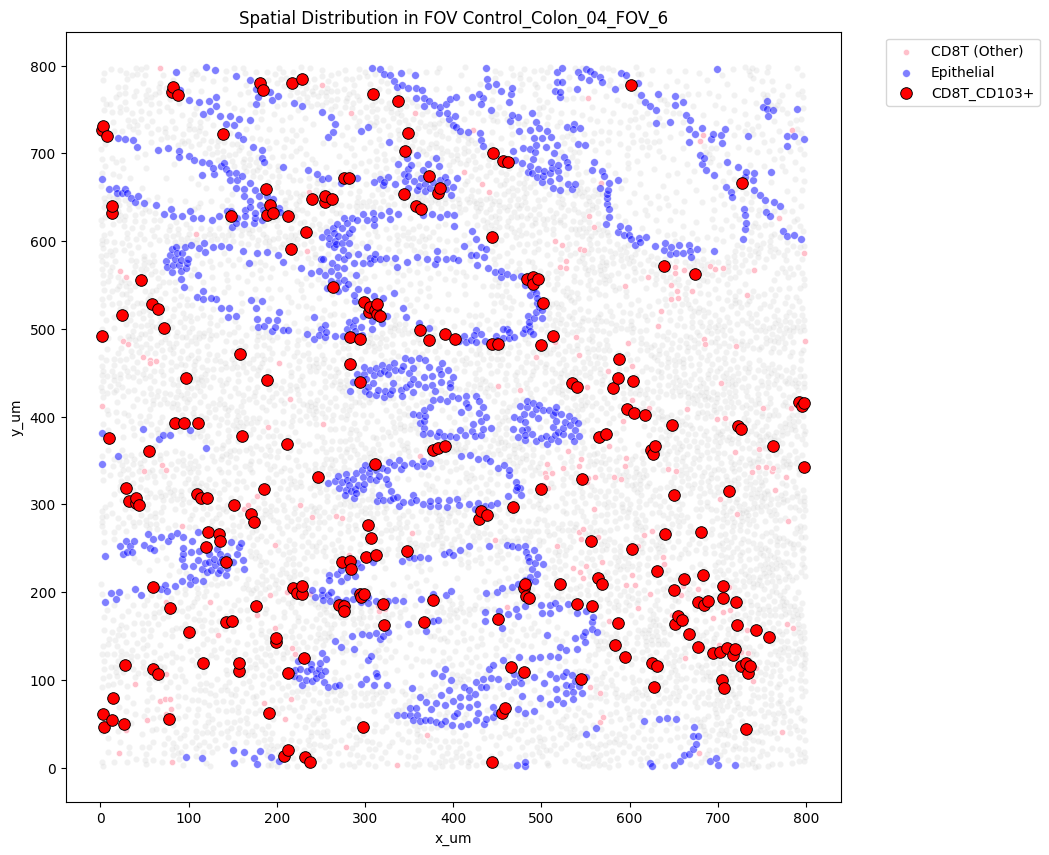

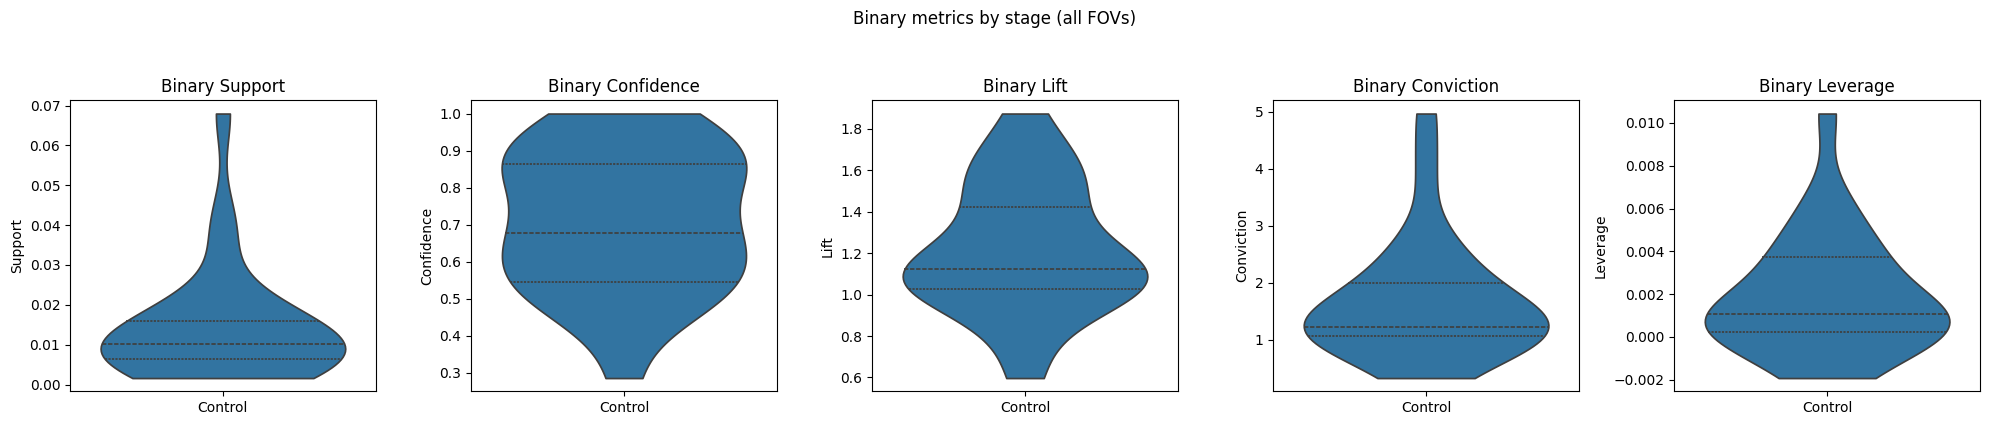

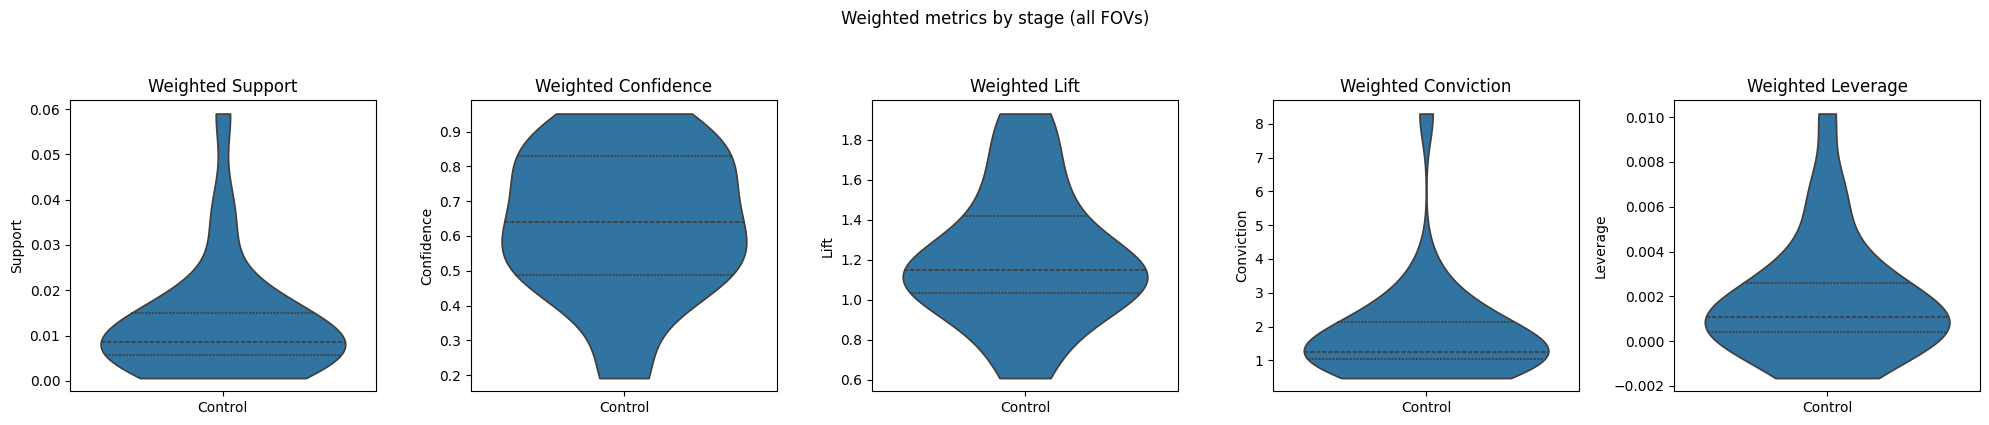

In [5]:
metrics = evaluate_cohort("Colon - Control", colon_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Mild

FOV: GVHD_13_FOV_1 | Transactions: 1462
  [Binary]   Sup: 0.0014 | Conf: 1.0000 | Lift: 1.0951 | PASS: False
  [Weighted] Sup: 0.0014 | Conf: 1.0000 | Lift: 1.1450 | PASS: False

FOV: GVHD_13_FOV_2 | Transactions: 1661
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_13_FOV_3 | Transactions: 1294
  [Binary]   Sup: 0.0008 | Conf: 1.0000 | Lift: 1.1041 | PASS: False
  [Weighted] Sup: 0.0008 | Conf: 1.0000 | Lift: 1.1566 | PASS: False

FOV: GVHD_17_FOV_1 | Transactions: 1503
  [Binary]   Sup: 0.0013 | Conf: 1.0000 | Lift: 1.2609 | PASS: False
  [Weighted] Sup: 0.0013 | Conf: 1.0000 | Lift: 1.3489 | PASS: False

FOV: GVHD_17_FOV_2 | Transactions: 1188
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_17_FOV_3 | Transactions: 1492
  [Binary]   Sup: 0.0020 | Conf:

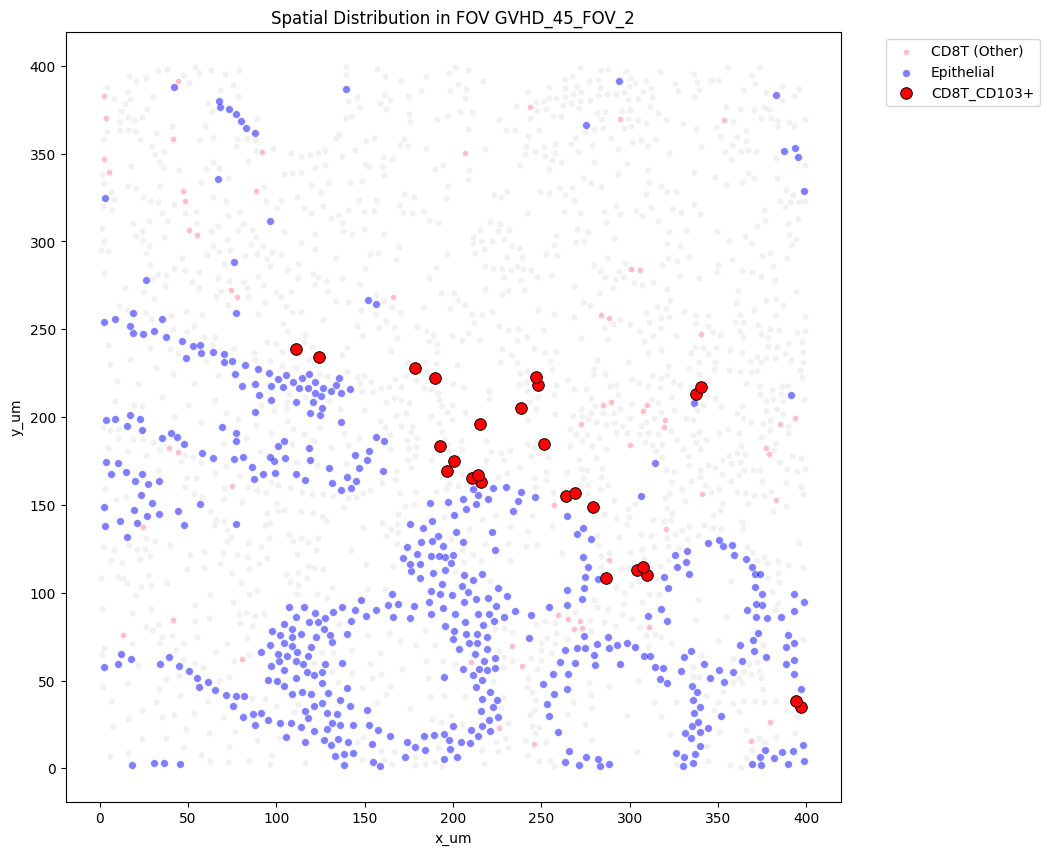

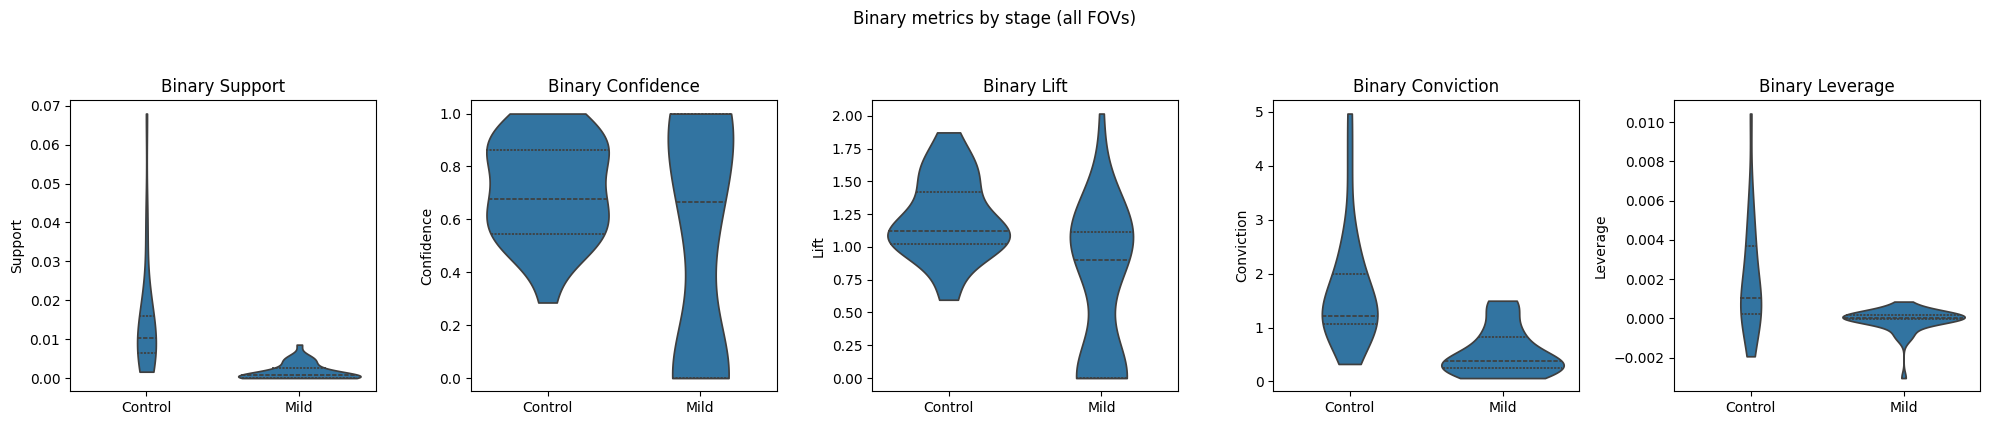

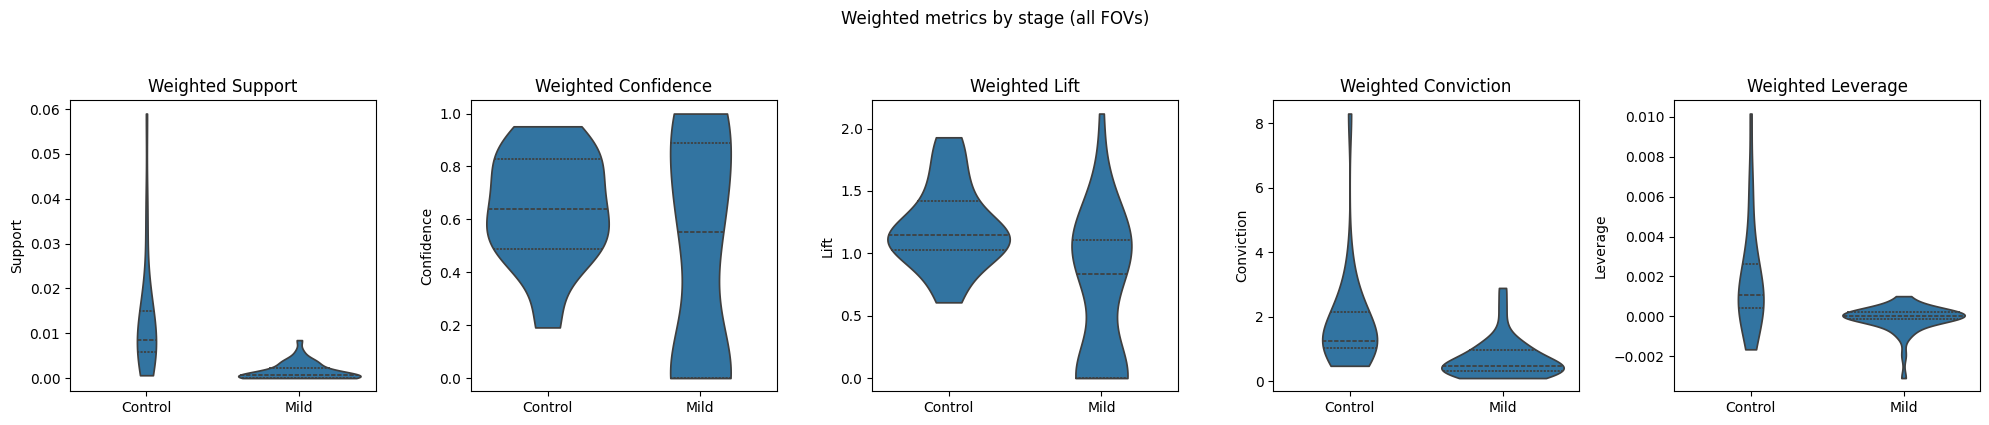

In [6]:
metrics = evaluate_cohort("Colon - Mild", colon_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Severe

FOV: GVHD_01_FOV_1 | Transactions: 1801
  [Binary]   Sup: 0.0050 | Conf: 1.0000 | Lift: 1.1200 | PASS: False
  [Weighted] Sup: 0.0048 | Conf: 0.9585 | Lift: 1.1148 | PASS: False

FOV: GVHD_01_FOV_2_R | Transactions: 2040
  [Binary]   Sup: 0.0010 | Conf: 1.0000 | Lift: 1.5875 | PASS: False
  [Weighted] Sup: 0.0010 | Conf: 1.0000 | Lift: 1.7422 | PASS: False

FOV: GVHD_01_FOV_3_R | Transactions: 1852
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_01_FOV_4 | Transactions: 1937
  [Binary]   Sup: 0.0005 | Conf: 1.0000 | Lift: 1.0358 | PASS: False
  [Weighted] Sup: 0.0005 | Conf: 1.0000 | Lift: 1.0711 | PASS: False

FOV: GVHD_01_FOV_5 | Transactions: 2103
  [Binary]   Sup: 0.0038 | Conf: 1.0000 | Lift: 1.2503 | PASS: False
  [Weighted] Sup: 0.0037 | Conf: 0.9826 | Lift: 1.2927 | PASS: False

FOV: GVHD_01_FOV_6_R | Transactions: 2010
  [Binary]   Sup: 0.0000

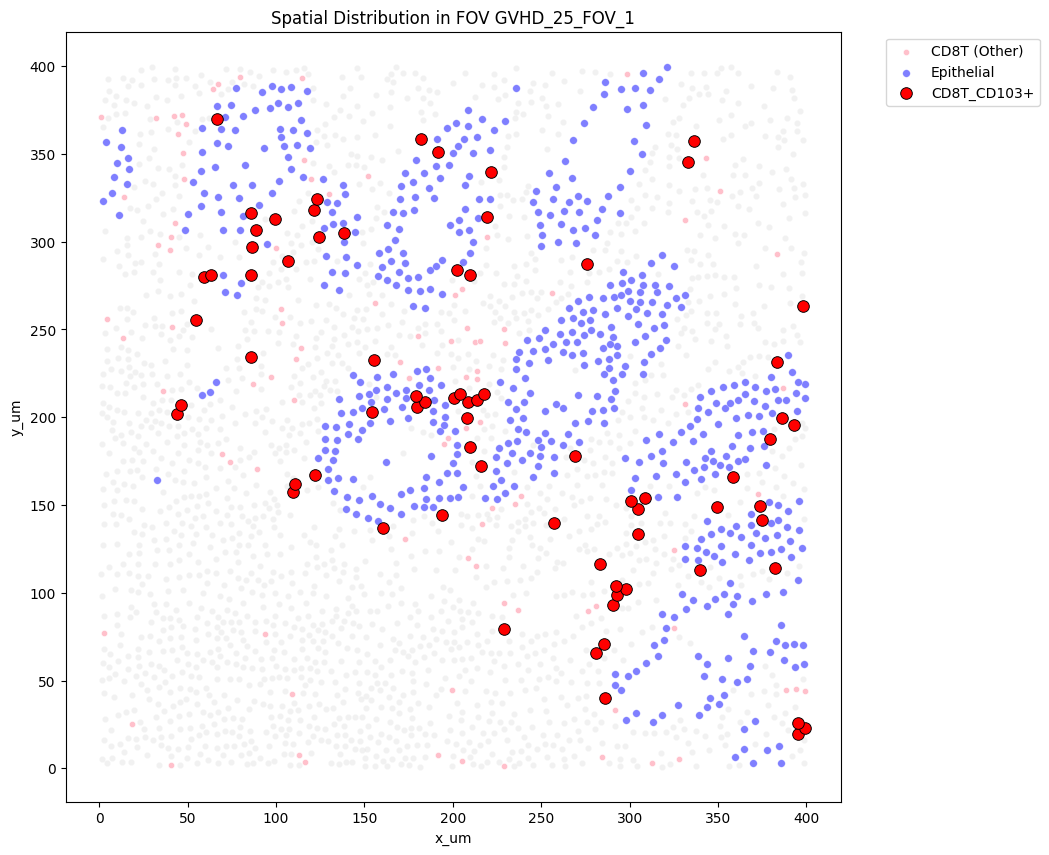

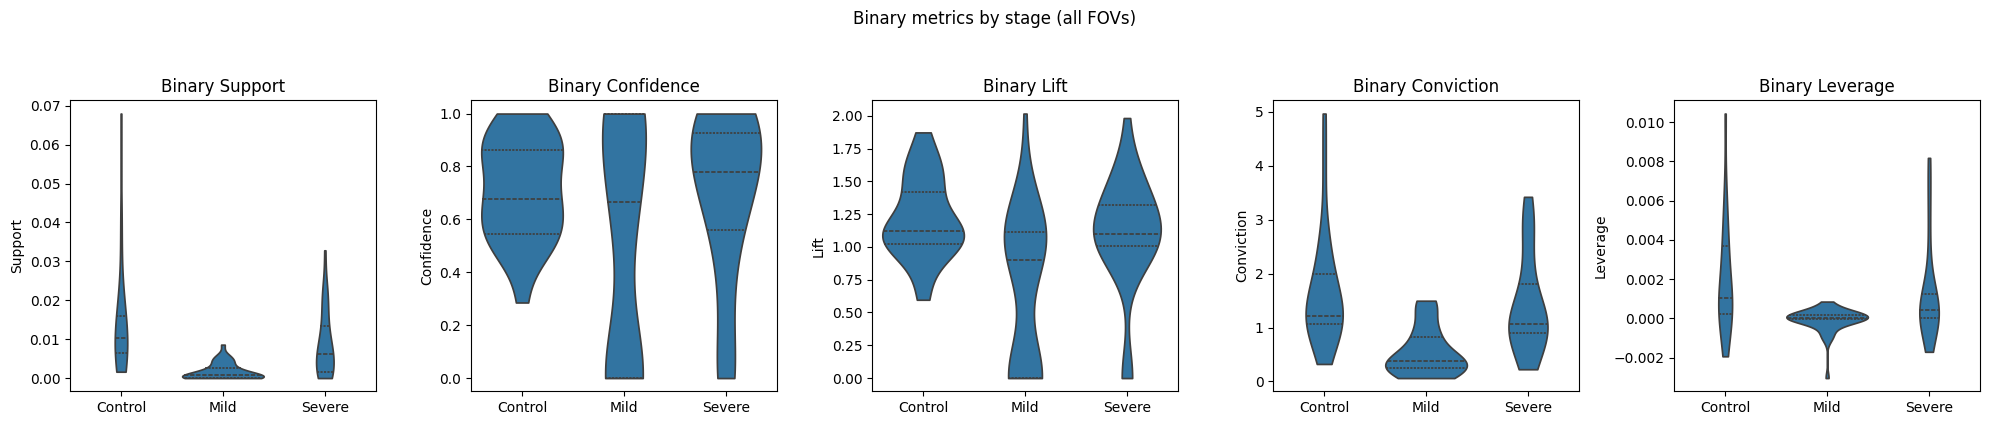

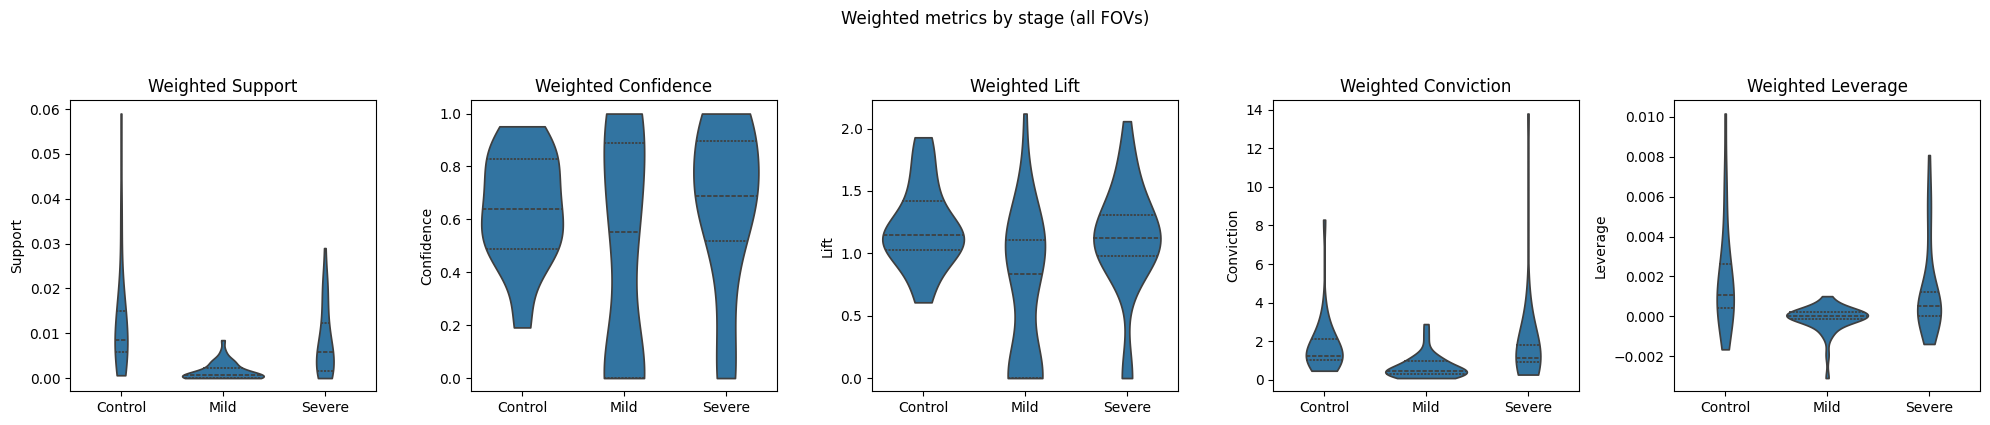

In [7]:
metrics = evaluate_cohort("Colon - Severe", colon_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_distributions(STAGE_FOV_METRICS, organ="Colon", stage_column=STAGE_COLUMN)


Evaluating Cohort: Duodenum - Control

FOV: Control_01_FOV_1 | Transactions: 2618
  [Binary]   Sup: 0.0195 | Conf: 0.6986 | Lift: 1.4834 | PASS: True
  [Weighted] Sup: 0.0182 | Conf: 0.6534 | Lift: 1.5319 | PASS: True

FOV: Control_01_FOV_2 | Transactions: 2354
  [Binary]   Sup: 0.0421 | Conf: 0.8919 | Lift: 1.1657 | PASS: False
  [Weighted] Sup: 0.0392 | Conf: 0.8310 | Lift: 1.1670 | PASS: False

FOV: Control_01_FOV_3 | Transactions: 2157
  [Binary]   Sup: 0.0241 | Conf: 0.7123 | Lift: 0.9688 | PASS: False
  [Weighted] Sup: 0.0237 | Conf: 0.7009 | Lift: 0.9833 | PASS: False

FOV: Control_01_FOV_4 | Transactions: 2140
  [Binary]   Sup: 0.0150 | Conf: 0.9143 | Lift: 0.9822 | PASS: False
  [Weighted] Sup: 0.0144 | Conf: 0.8826 | Lift: 0.9767 | PASS: False

FOV: Control_02_FOV_1 | Transactions: 2305
  [Binary]   Sup: 0.0074 | Conf: 0.6800 | Lift: 0.9358 | PASS: False
  [Weighted] Sup: 0.0071 | Conf: 0.6536 | Lift: 0.9514 | PASS: False

FOV: Control_02_FOV_2 | Transactions: 2048
  [Binary]

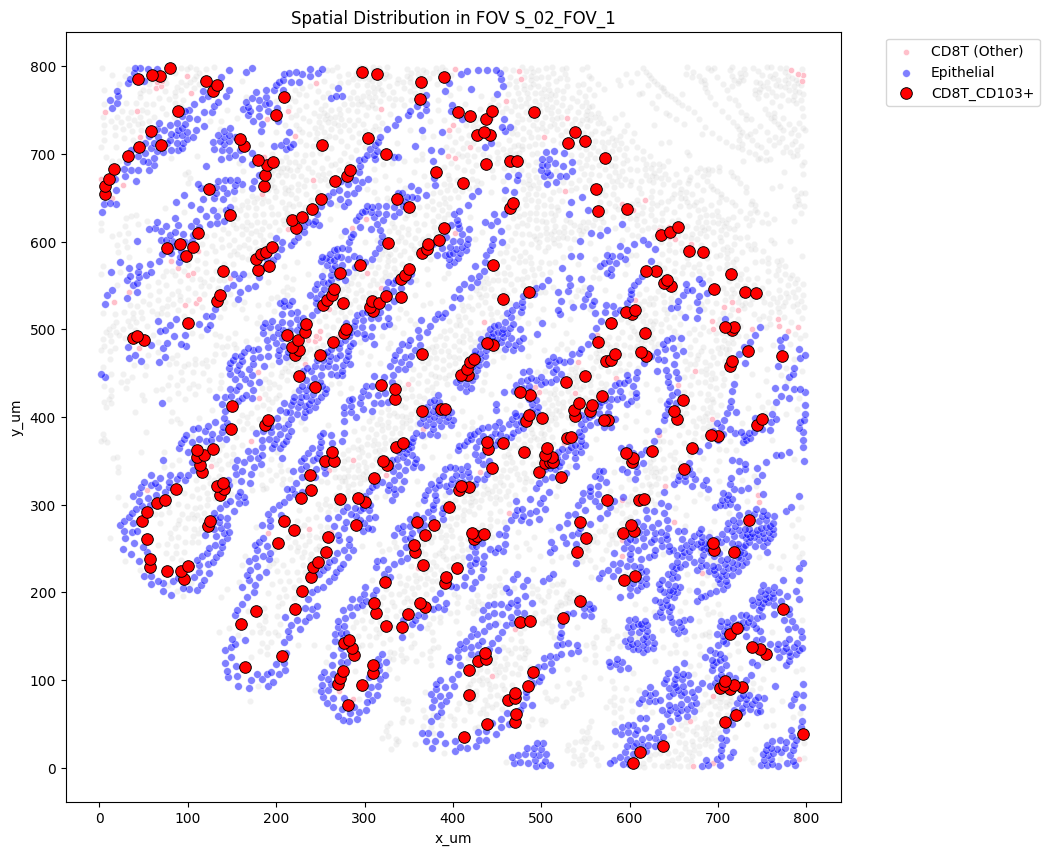

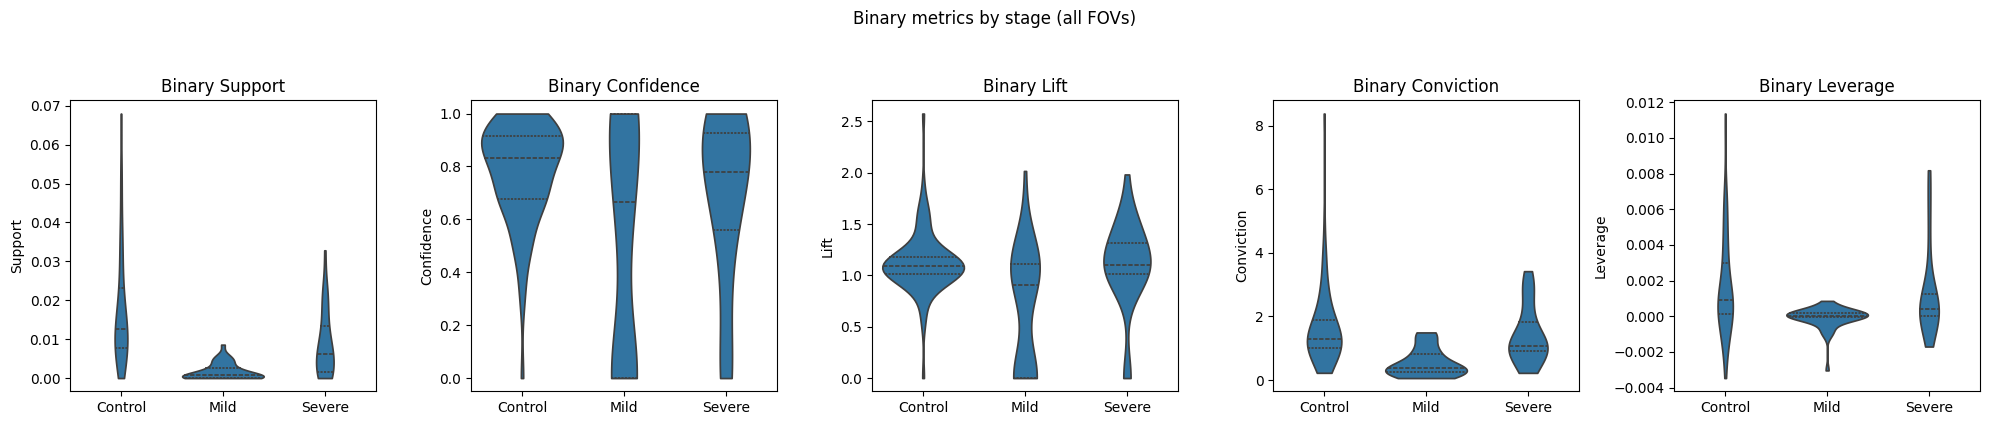

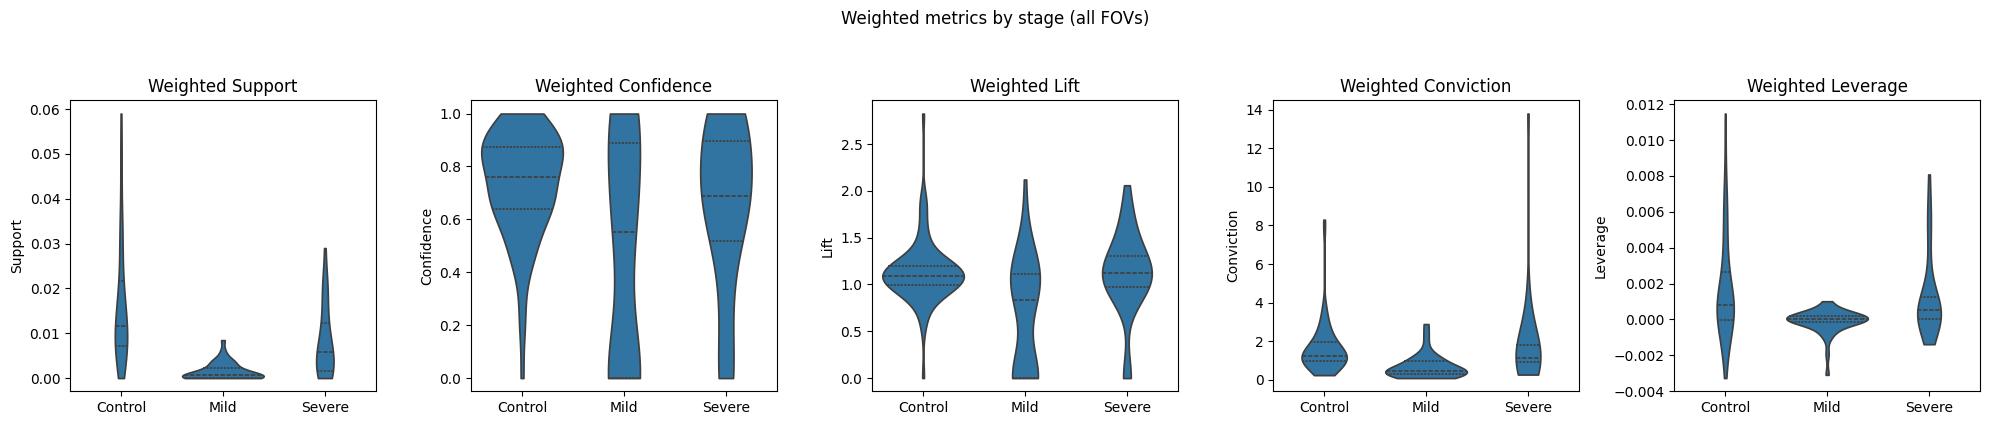

In [8]:
metrics = evaluate_cohort("Duodenum - Control", duodenum_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Mild

FOV: GVHD_03_FOV_1_R | Transactions: 2879
  [Binary]   Sup: 0.0049 | Conf: 0.5600 | Lift: 0.8888 | PASS: False
  [Weighted] Sup: 0.0045 | Conf: 0.5216 | Lift: 0.8819 | PASS: False

FOV: GVHD_03_FOV_2 | Transactions: 2524
  [Binary]   Sup: 0.0008 | Conf: 0.2500 | Lift: 0.4266 | PASS: False
  [Weighted] Sup: 0.0007 | Conf: 0.2190 | Lift: 0.3965 | PASS: False

FOV: GVHD_03_FOV_3_R | Transactions: 2615
  [Binary]   Sup: 0.0008 | Conf: 1.0000 | Lift: 1.3362 | PASS: False
  [Weighted] Sup: 0.0005 | Conf: 0.7030 | Lift: 1.0073 | PASS: False

FOV: GVHD_03_FOV_4 | Transactions: 2443
  [Binary]   Sup: 0.0029 | Conf: 0.7778 | Lift: 1.0394 | PASS: False
  [Weighted] Sup: 0.0026 | Conf: 0.7132 | Lift: 1.0008 | PASS: False

FOV: GVHD_04_FOV_1 | Transactions: 2177
  [Binary]   Sup: 0.0014 | Conf: 0.3750 | Lift: 0.5994 | PASS: False
  [Weighted] Sup: 0.0009 | Conf: 0.2547 | Lift: 0.4203 | PASS: False

FOV: GVHD_04_FOV_2 | Transactions: 2031
  [Binary]   Sup: 0.0015 

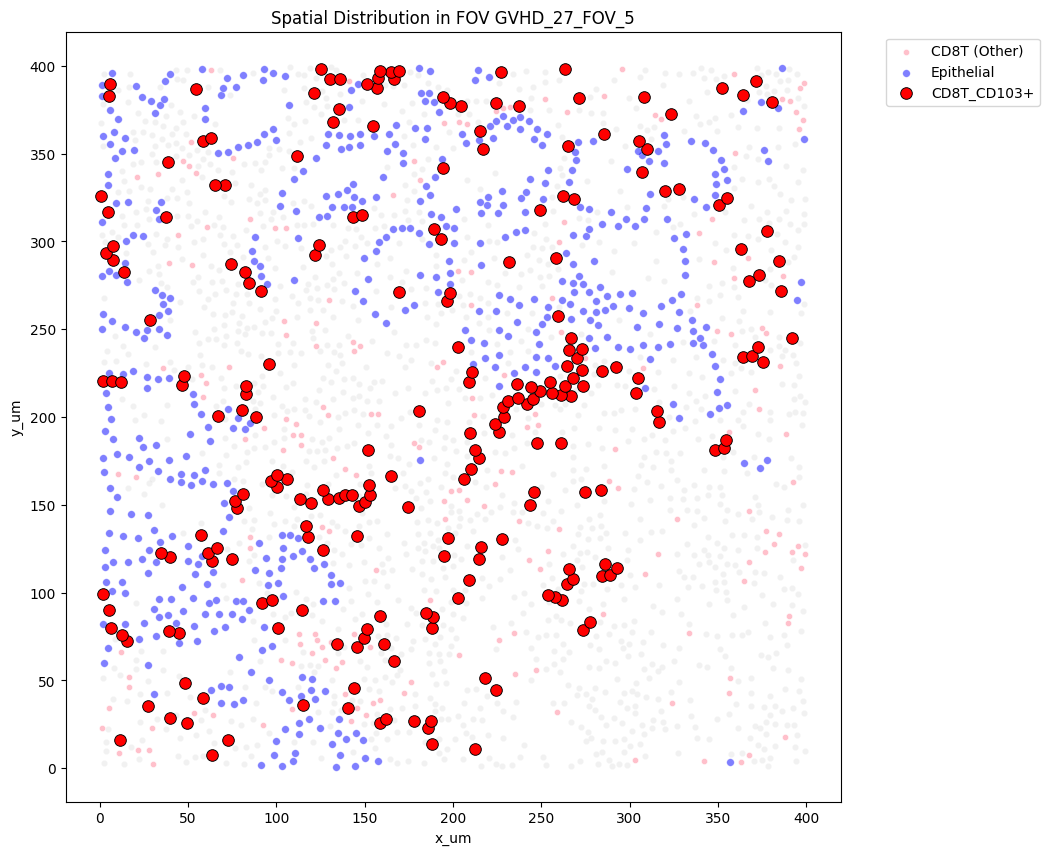

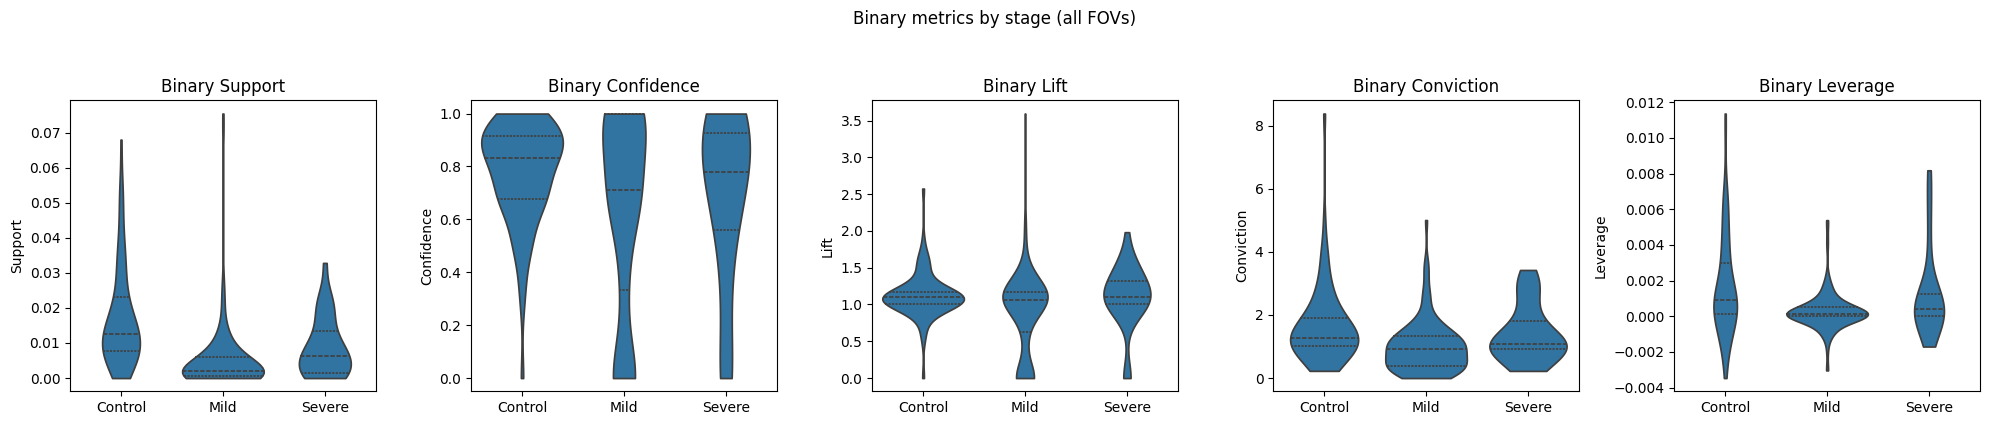

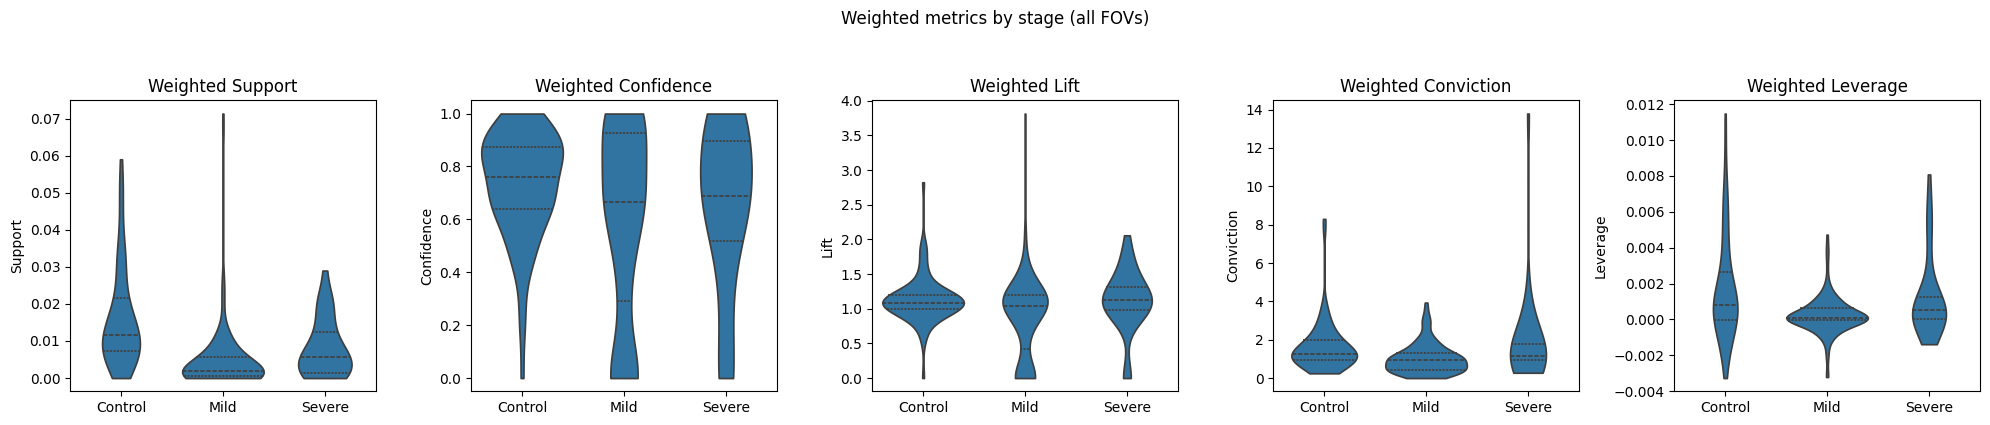

In [9]:
metrics = evaluate_cohort("Duodenum - Mild", duodenum_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Severe

FOV: GVHD_02_FOV_1_R | Transactions: 1977
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_02_FOV_2_R | Transactions: 1722
  [Binary]   Sup: 0.0012 | Conf: 0.6667 | Lift: 1.6662 | PASS: False
  [Weighted] Sup: 0.0012 | Conf: 0.6667 | Lift: 2.0729 | PASS: False

FOV: GVHD_06_FOV_1 | Transactions: 2174
  [Binary]   Sup: 0.0005 | Conf: 0.1111 | Lift: 0.5053 | PASS: False
  [Weighted] Sup: 0.0004 | Conf: 0.0849 | Lift: 0.5973 | PASS: False

FOV: GVHD_06_FOV_2 | Transactions: 2265
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_3 | Transactions: 1998
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_4 | Transactions: 2040
  [Binary]   Sup: 0.003

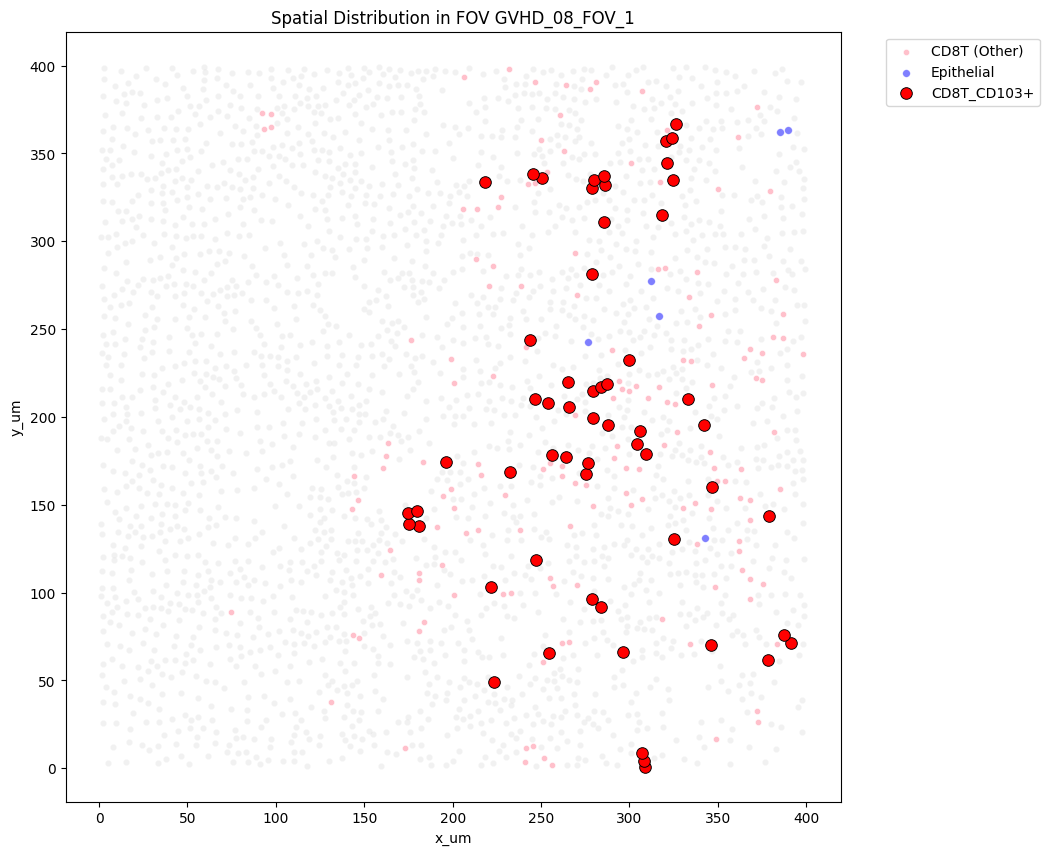

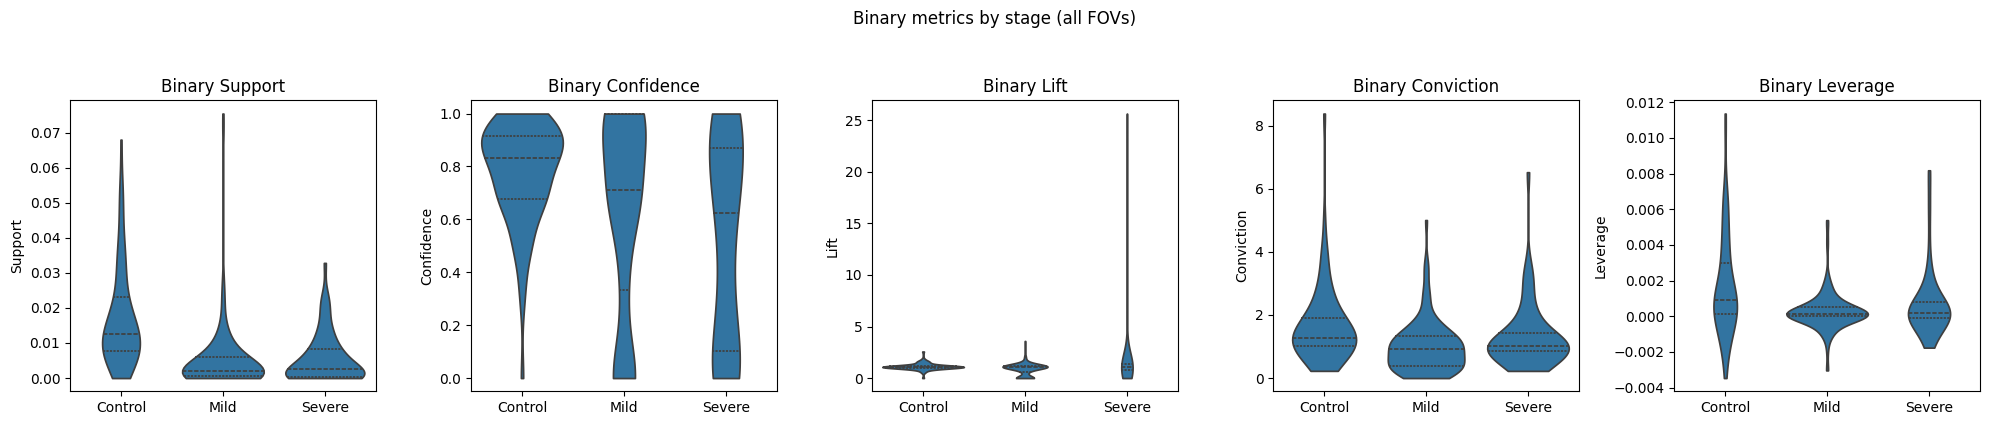

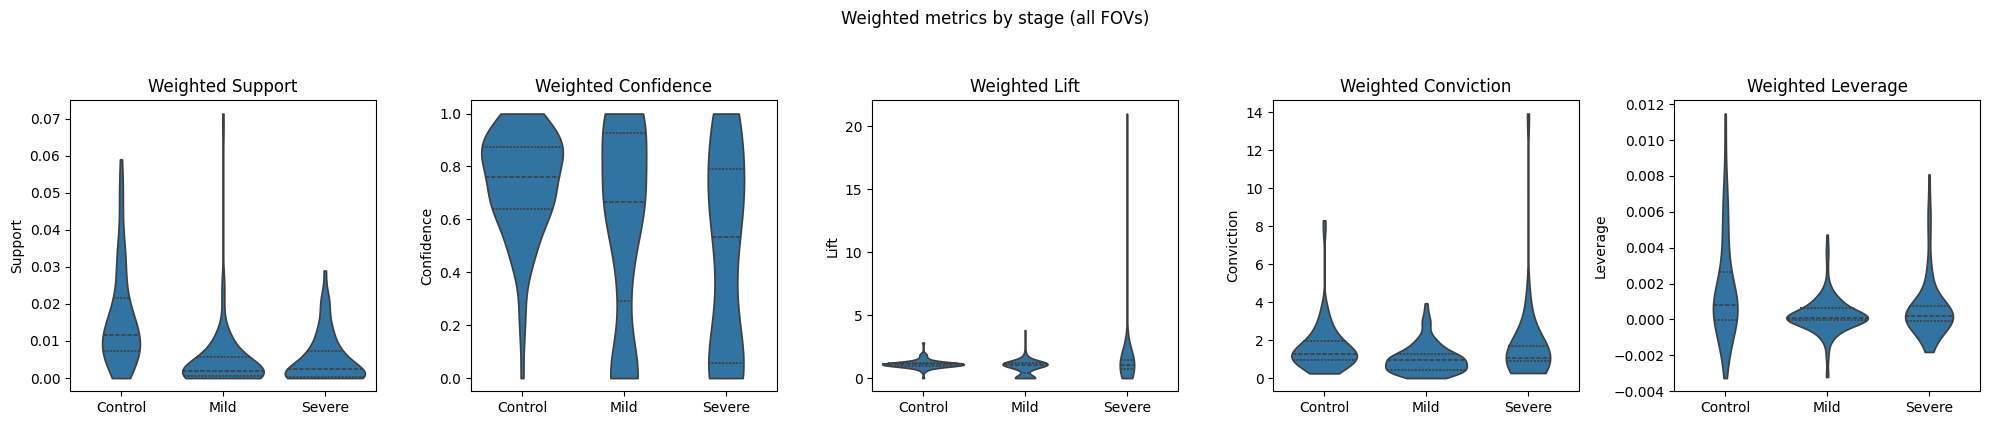

In [10]:
metrics = evaluate_cohort("Duodenum - Severe", duodenum_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_distributions(STAGE_FOV_METRICS, organ="Duodenum", stage_column=STAGE_COLUMN)
